# 7.2 价值因子：为什么"便宜的股票"长期跑赢？

## 本节的核心问题

如果你在 1926-2023 年间，每年系统性地持有**低 P/B 股票**（按 P/B 升序排列的最低 20%），
并做空高 P/B 股票（最高 20%），累计回报会比市场好多少？

答案：**多 3-5 个百分点**（年化）。这就是 **价值溢价（Value Premium）**。

这并不是偶然——它是 Fama & French（1992）被引用最多的学术发现之一。
但更重要的问题是：**为什么**会有这种溢价？它未来还会存在吗？

## 学习目标
- 深度理解价值溢价的两种解释：风险补偿 vs 行为偏差
- 掌握 P/E、P/B、PS 三种价值指标的差异和适用场景
- 实践因子 IC 分析、分位数回测
- 理解价值因子为何在 2010-2021 年「失效」以及背后的逻辑


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 第一部分：价值溢价的两大解释

在开始计算之前，必须搞清楚**为什么低 P/B 股票应该跑赢**——
只有理解了 "为什么"，才能判断这种现象未来是否还会持续。

---

### 解释一：**风险补偿论**（Fama & French 的立场）

低 P/B 公司通常是处于困境的公司：
- 营收下滑、盈利下降，甚至面临破产风险
- 市场账面价值下跌，但股价下跌更多（所以 P/B 低）

**这种公司风险更大**，因此投资者要求更高的回报作为补偿。
就像高收益债券（「垃圾债」）的利率更高，是因为违约风险更大。

> **风险补偿论的含义**：价值溢价会持续存在，因为它是真实风险的合理补偿。

---

### 解释二：**行为偏差论**（行为金融学派的立场）

投资者倾向于将近期的好/坏业绩**过度外推**到未来：
- 成长股（高 P/E、高 P/B）近期业绩好 → 投资者乐观预期未来也好 → 股价被高估
- 价值股（低 P/E、低 P/B）近期业绩差 → 投资者悲观预期未来也差 → 股价被低估

随着时间推移，成长股无法维持超高增速（均值回归），
价值股也没有市场预期的那么差，因此出现**价格修正**。

> **行为偏差论的含义**：如果越来越多人知道并交易这个规律，溢价可能缩小甚至消失。

---

### 三种主要价值指标的使用场景

| 指标 | 计算 | 适用场景 | 局限 |
|------|------|---------|------|
| **P/E** | 市值/净利润 | 盈利稳定的成熟企业 | 周期性行业利润波动大导致 P/E 失真 |
| **P/B** | 市值/股东权益 | 重资产行业（银行、地产） | 轻资产/科技公司账面价值不反映真实价值 |
| **PS** | 市值/营业收入 | 亏损但有营收的成长公司 | 利润率极低的公司 PS 可能仍然被高估 |
| **EV/EBITDA** | 企业价值/EBITDA | 跨资本结构比较 | 需要更多数据计算 |


In [3]:
# 模拟横截面数据：验证价值指标与未来收益的负相关关系
np.random.seed(42)
n = 300

# 模拟真实分布：价值指标有偏（少量极端高估值）
PE = np.random.lognormal(mean=np.log(15), sigma=0.6, size=n).clip(3, 80)
PB = np.random.lognormal(mean=np.log(2.0), sigma=0.7, size=n).clip(0.3, 15)
PS = np.random.lognormal(mean=np.log(1.5), sigma=0.8, size=n).clip(0.2, 10)

# 前瞻 12 月收益率：与价值指标负相关（价值溢价）+ 噪音
noise = np.random.normal(0, 0.25, n)
# 低 PE → 未来收益更高（价值溢价）
fwd_ret_12m = (-0.003 * PE          # PE 效应
               - 0.05 * np.log(PB)  # PB 效应（取 log 因为是倍数）
               - 0.04 * np.log(PS)  # PS 效应
               + noise)

df = pd.DataFrame({'PE': PE, 'PB': PB, 'PS': PS, 'fwd_ret': fwd_ret_12m})

# 计算并展示各指标与未来收益的相关性
print('价值指标与前瞻 12 月收益的 Spearman 相关系数：')
for col in ['PE', 'PB', 'PS']:
    ic, p = stats.spearmanr(df[col], df['fwd_ret'])
    print(f'  {col} IC = {ic:+.4f}  (p = {p:.4f})  '
          f'{"✓ 显著负相关（价值溢价）" if p < 0.05 else "✗ 不显著"}')
print()
print('负 IC 含义：PE/PB/PS 越低的股票，未来收益越高 → 价值溢价存在')


价值指标与前瞻 12 月收益的 Spearman 相关系数：
  PE IC = -0.0352  (p = 0.5438)  ✗ 不显著
  PB IC = -0.1639  (p = 0.0044)  ✓ 显著负相关（价值溢价）
  PS IC = -0.1173  (p = 0.0423)  ✓ 显著负相关（价值溢价）

负 IC 含义：PE/PB/PS 越低的股票，未来收益越高 → 价值溢价存在


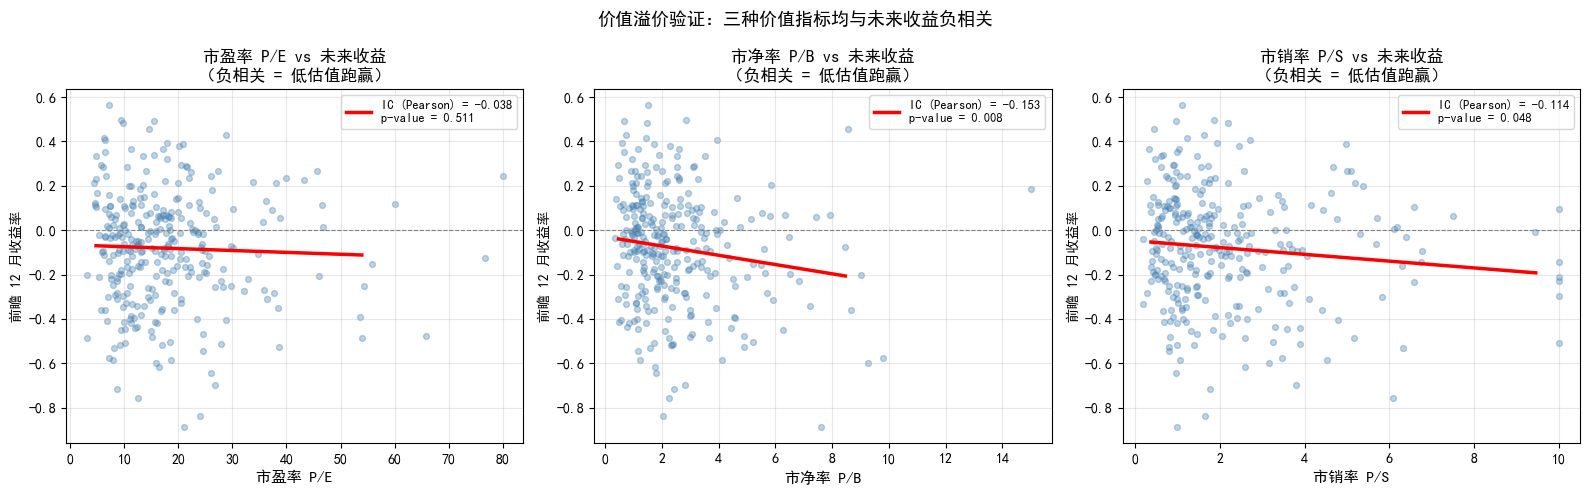

In [4]:
# 可视化：价值指标 vs 未来收益的散点图
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, x_col, label in zip(axes, ['PE','PB','PS'], ['市盈率 P/E','市净率 P/B','市销率 P/S']):
    ax.scatter(df[x_col], df['fwd_ret'], alpha=0.35, s=18, color='steelblue')
    # 添加趋势线
    m, b, r, p, se = stats.linregress(df[x_col], df['fwd_ret'])
    xr = np.linspace(df[x_col].quantile(0.02), df[x_col].quantile(0.98), 100)
    ax.plot(xr, m*xr+b, 'r-', lw=2.5,
            label=f'IC (Pearson) = {r:.3f}\np-value = {p:.3f}')
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('前瞻 12 月收益率', fontsize=10)
    ax.set_title(f'{label} vs 未来收益\n（负相关 = 低估值跑赢）')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('价值溢价验证：三种价值指标均与未来收益负相关', fontsize=13)
plt.tight_layout()
plt.show()


## 第二部分：因子 IC 分析——评估因子质量的标准工具

**IC（信息系数，Information Coefficient）** 是因子研究中最重要的质量指标。

$$IC_t = \text{Spearman}\left(\text{因子得分}_t, \text{下期收益率}_t\right)$$

- IC > 0：因子得分高 → 未来收益高（正向因子）
- IC < 0：因子得分低 → 未来收益高（反向因子，如 PE：低 PE 跑赢）
- |IC| 通常在 0.02~0.08 之间（量化因子的现实水平）

> **IC 0.05 就已经是非常强的因子**！不要被数字的绝对值误导。
> 一个 IC=0.05 的日频因子，年化信息比约为 0.79，足以构建超额收益策略。

**ICIR（IC 信息比率）** = 均值 IC / IC 标准差
- ICIR > 0.5 → 因子信号稳健
- ICIR > 1.0 → 非常强的因子


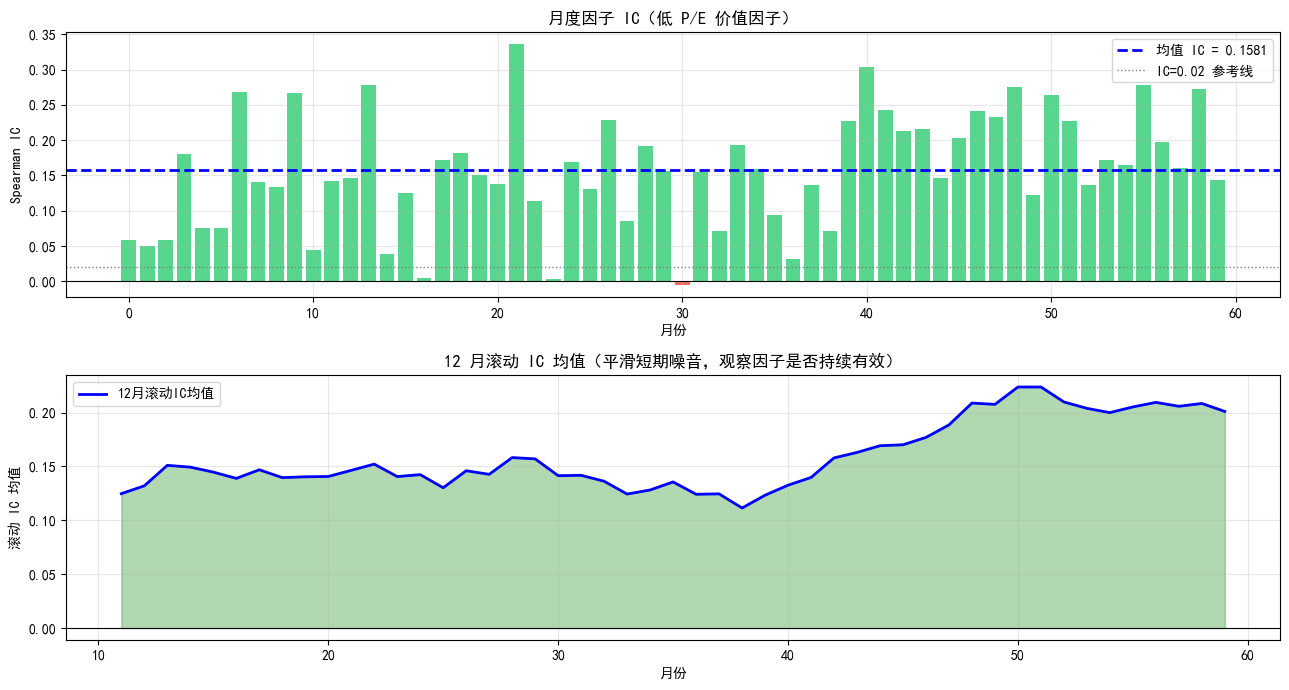

=== 因子质量评估报告 ===
均值 IC:    0.1581
IC 标准差:  0.0809
ICIR:       1.9533  ✓ 稳健
正 IC 月占比: 98.3%  ✓ 方向一致


In [5]:
# 模拟 60 个月的月度 IC 序列（模拟价值因子的实际表现）
np.random.seed(42)
monthly_ICs = []

for month in range(60):
    # 每期重新模拟截面数据（模拟真实情况：IC 不稳定）
    pe = np.random.lognormal(np.log(15), 0.6, 200)
    # 低 PE 跑赢，但有噪音
    ret = -0.003 * pe + np.random.normal(0, 0.20, 200)
    ic, _ = stats.spearmanr(pe, ret)
    monthly_ICs.append(-ic)  # 取负号：低PE→高收益，转换为正向IC

ic_series = pd.Series(monthly_ICs, name='月度IC')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# 上图：月度 IC 柱状图
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in ic_series]
axes[0].bar(range(len(ic_series)), ic_series, color=colors, alpha=0.8, width=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(ic_series.mean(), color='blue', lw=2, linestyle='--',
                label=f'均值 IC = {ic_series.mean():.4f}')
axes[0].axhline(0.02, color='gray', linestyle=':', lw=1, label='IC=0.02 参考线')
axes[0].set_title('月度因子 IC（低 P/E 价值因子）', fontsize=12)
axes[0].set_xlabel('月份')
axes[0].set_ylabel('Spearman IC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 下图：12 月滚动 IC 均值（平滑噪音）
ic_roll12 = ic_series.rolling(12).mean()
axes[1].plot(range(len(ic_roll12)), ic_roll12, 'b-', lw=2, label='12月滚动IC均值')
axes[1].fill_between(range(len(ic_roll12)), ic_roll12, 0,
                     where=(ic_roll12 > 0), alpha=0.3, color='green')
axes[1].fill_between(range(len(ic_roll12)), ic_roll12, 0,
                     where=(ic_roll12 < 0), alpha=0.3, color='red')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('12 月滚动 IC 均值（平滑短期噪音，观察因子是否持续有效）', fontsize=12)
axes[1].set_xlabel('月份')
axes[1].set_ylabel('滚动 IC 均值')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 统计摘要
pos_rate = (ic_series > 0).mean()
icir = ic_series.mean() / ic_series.std()
print(f'=== 因子质量评估报告 ==='  )
print(f'均值 IC:    {ic_series.mean():.4f}')
print(f'IC 标准差:  {ic_series.std():.4f}')
print(f'ICIR:       {icir:.4f}  {"✓ 稳健" if icir > 0.5 else "⚠ 偏低"}'  )
print(f'正 IC 月占比: {pos_rate:.1%}  {"✓ 方向一致" if pos_rate > 0.55 else "⚠ 正负各半"}'  )


## 第三部分：价值因子 vs 成长因子——为什么会有轮动？

价值因子不是在任何时候都有效的。历史上有两段著名的失效期：
1. **1998-2000 年科网泡沫**：成长股（高 PE）被过度追捧，价值股被抛弃
2. **2010-2021 年**：美联储长期低利率 + 科技巨头垄断性增长，成长因子连续跑赢价值因子

**为什么利率与价值/成长轮动有关？**

这是价值因子最重要但最少被解释的机制：

> 用 Gordon 增长模型理解：股票价值 = $\frac{D_1}{r - g}$
>
> - 成长股（高 g）的价值对折现率 r 更敏感——利率越低，成长股估值提升越多
> - 价值股（低 g）受利率影响较小，往往有更多当期现金流

当利率从 6% 降到 2%（2010-2021 美联储 QE），成长股受益远大于价值股。
当利率从 0% 升至 5%（2022-2023 加息），价值股大幅反弹，成长股受损。

这就是为什么 **2022 年价值因子大幅跑赢**。


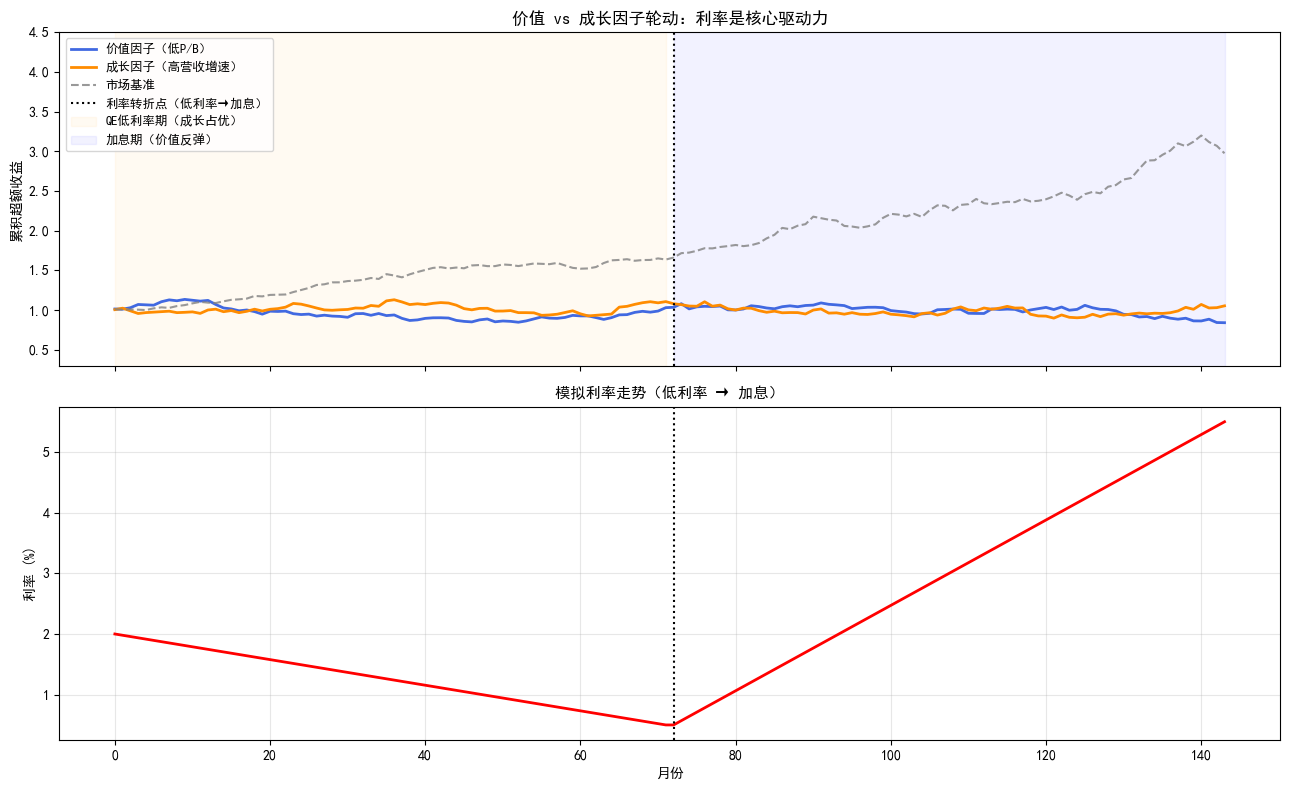

关键结论：
  QE期（前72月）价值累计: 1.03x  成长累计: 1.11x  → 成长占优
  加息期（后72月）价值累计: 0.82x  成长累计: 0.95x  → 价值反弹


In [6]:
# 模拟价值 vs 成长的历史轮动
np.random.seed(42)
months = 144  # 12年

# 模拟利率环境：前72月低利率（QE），后72月加息
interest_rate_env = np.concatenate([
    np.linspace(0.02, 0.005, 72),  # 低利率：利好成长
    np.linspace(0.005, 0.055, 72)  # 加息：利好价值
])

# 价值因子收益与利率正相关，成长因子与利率负相关
value_drift  = 0.002 - 3.0 * (interest_rate_env - 0.025)   # 低利率 → 价值跑输
growth_drift = 0.002 + 3.0 * (interest_rate_env - 0.025)   # 低利率 → 成长跑赢

value_returns  = value_drift/12 + np.random.normal(0, 0.025, months)
growth_returns = growth_drift/12 + np.random.normal(0, 0.025, months)

cum_value  = (1 + pd.Series(value_returns )).cumprod()
cum_growth = (1 + pd.Series(growth_returns)).cumprod()
cum_market = (1 + pd.Series(np.random.normal(0.006, 0.018, months))).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(cum_value,  'royalblue', lw=2, label='价值因子（低P/B）')
axes[0].plot(cum_growth, 'darkorange', lw=2, label='成长因子（高营收增速）')
axes[0].plot(cum_market, 'gray',       lw=1.5, linestyle='--', alpha=0.8, label='市场基准')
axes[0].axvline(72, color='black', linestyle=':', lw=1.5, label='利率转折点（低利率→加息）')
axes[0].fill_between(range(72), 0, 5, alpha=0.05, color='orange', label='QE低利率期（成长占优）')
axes[0].fill_between(range(72, months), 0, 5, alpha=0.05, color='blue', label='加息期（价值反弹）')
axes[0].set_title('价值 vs 成长因子轮动：利率是核心驱动力', fontsize=12)
axes[0].set_ylabel('累积超额收益')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.3, 4.5)

# 下图：利率走势
axes[1].plot(interest_rate_env * 100, 'red', lw=2)
axes[1].axvline(72, color='black', linestyle=':', lw=1.5)
axes[1].set_title('模拟利率走势（低利率 → 加息）', fontsize=11)
axes[1].set_xlabel('月份')
axes[1].set_ylabel('利率 (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('关键结论：')
print(f'  QE期（前72月）价值累计: {cum_value.iloc[71]:.2f}x  成长累计: {cum_growth.iloc[71]:.2f}x  → 成长占优')
print(f'  加息期（后72月）价值累计: {cum_value.iloc[-1]/cum_value.iloc[71]:.2f}x  成长累计: {cum_growth.iloc[-1]/cum_growth.iloc[71]:.2f}x  → 价值反弹')


## 🎯 练习

1. 从公开数据（Wind/Bloomberg，或 CSMAR 学术数据库）获取 A 股 2015-2024 年的月度 P/B 数据，重新计算低 P/B 组和高 P/B 组的年化收益差，中国市场的价值溢价有多显著？
2. 将 P/E、P/B、P/S 三个指标等权合成一个「综合价值得分」（先分别取排名再平均），对比单因子 IC，合成因子是否更稳定？
3. 研究 2016-2021 年 A 股「价值陷阱」：找出 5 只 P/B < 0.5 但长期跑输市场的股票，分析其 F-Score。

---
**下一节** → `03_quality_factors.ipynb`